# GTSRB Dataset Exploration

This notebook explores the German Traffic Sign Recognition Benchmark (GTSRB) dataset and prepares it for training a road sign recognition model.

In [1]:
# Import necessary libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

# Add the src directory to the path to import our modules
sys.path.append('../src')
from gtsrb_dataset import GTSRBDataset
from utils import apply_augmentation

/Users/bogdan/Desktop/Subjects WUT/Season 6/AI Fundamentals/road-sign-recognition/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Initialize the Dataset

First, we'll initialize the GTSRB dataset handler.

In [2]:
# Set the data directory path
data_dir = '../data/raw'

# Initialize the dataset handler
dataset = GTSRBDataset(data_dir, use_roi=True)

# Display the number of classes
print(f"Number of classes: {len(dataset.class_names)}")

# Display a few class names
for i in range(len(dataset.class_names)):
    print(f"Class {i}: {dataset.class_names.get(i, 'Unknown')}")

Loaded 43 class names from /Users/bogdan/Desktop/Subjects WUT/Season 6/AI Fundamentals/road-sign-recognition/src/gtsrb_class_map.json
Number of classes: 43
Class 0: Speed limit (20km/h)
Class 1: Speed limit (30km/h)
Class 2: Speed limit (50km/h)
Class 3: Speed limit (60km/h)
Class 4: Speed limit (70km/h)
Class 5: Speed limit (80km/h)
Class 6: End of speed limit (80km/h)
Class 7: Speed limit (100km/h)
Class 8: Speed limit (120km/h)
Class 9: No passing
Class 10: No passing for vehicles over 3.5 metric tons
Class 11: Right-of-way at the next intersection
Class 12: Priority road
Class 13: Yield
Class 14: Stop
Class 15: No vehicles
Class 16: Vehicles over 3.5 metric tons prohibited
Class 17: No entry
Class 18: General caution
Class 19: Dangerous curve to the left
Class 20: Dangerous curve to the right
Class 21: Double curve
Class 22: Bumpy road
Class 23: Slippery road
Class 24: Road narrows on the right
Class 25: Road work
Class 26: Traffic signals
Class 27: Pedestrians
Class 28: Children c

## Load Training Data

Now we'll load the training data. For exploration purposes, we'll limit the number of samples to keep processing time reasonable.

> **Note:** Loading the entire dataset (~39,000 images) can take several minutes and consume significant memory. Using a limit parameter (e.g., `limit=500`) is recommended during exploration.

In [3]:
# Load training data (limit to 500 samples for exploration)
train_images, train_labels = dataset.load_train_data(limit=500)  # Add explicit limit

print(f"\nLoaded {len(train_images)} training images with {len(np.unique(train_labels))} unique classes")
print(f"Image shapes range from {min(img.shape[0] for img in train_images)}x{min(img.shape[1] for img in train_images)} to {max(img.shape[0] for img in train_images)}x{max(img.shape[1] for img in train_images)}")

Loaded CSV file with 39209 rows
Limited to first 500 samples
Processing image 0/500
Loaded 500 images with 2 unique classes

Loaded 500 training images with 2 unique classes
Image shapes range from 15x16 to 125x137


## Visualize Sample Images

Let's visualize some sample images to get a feel for our data.

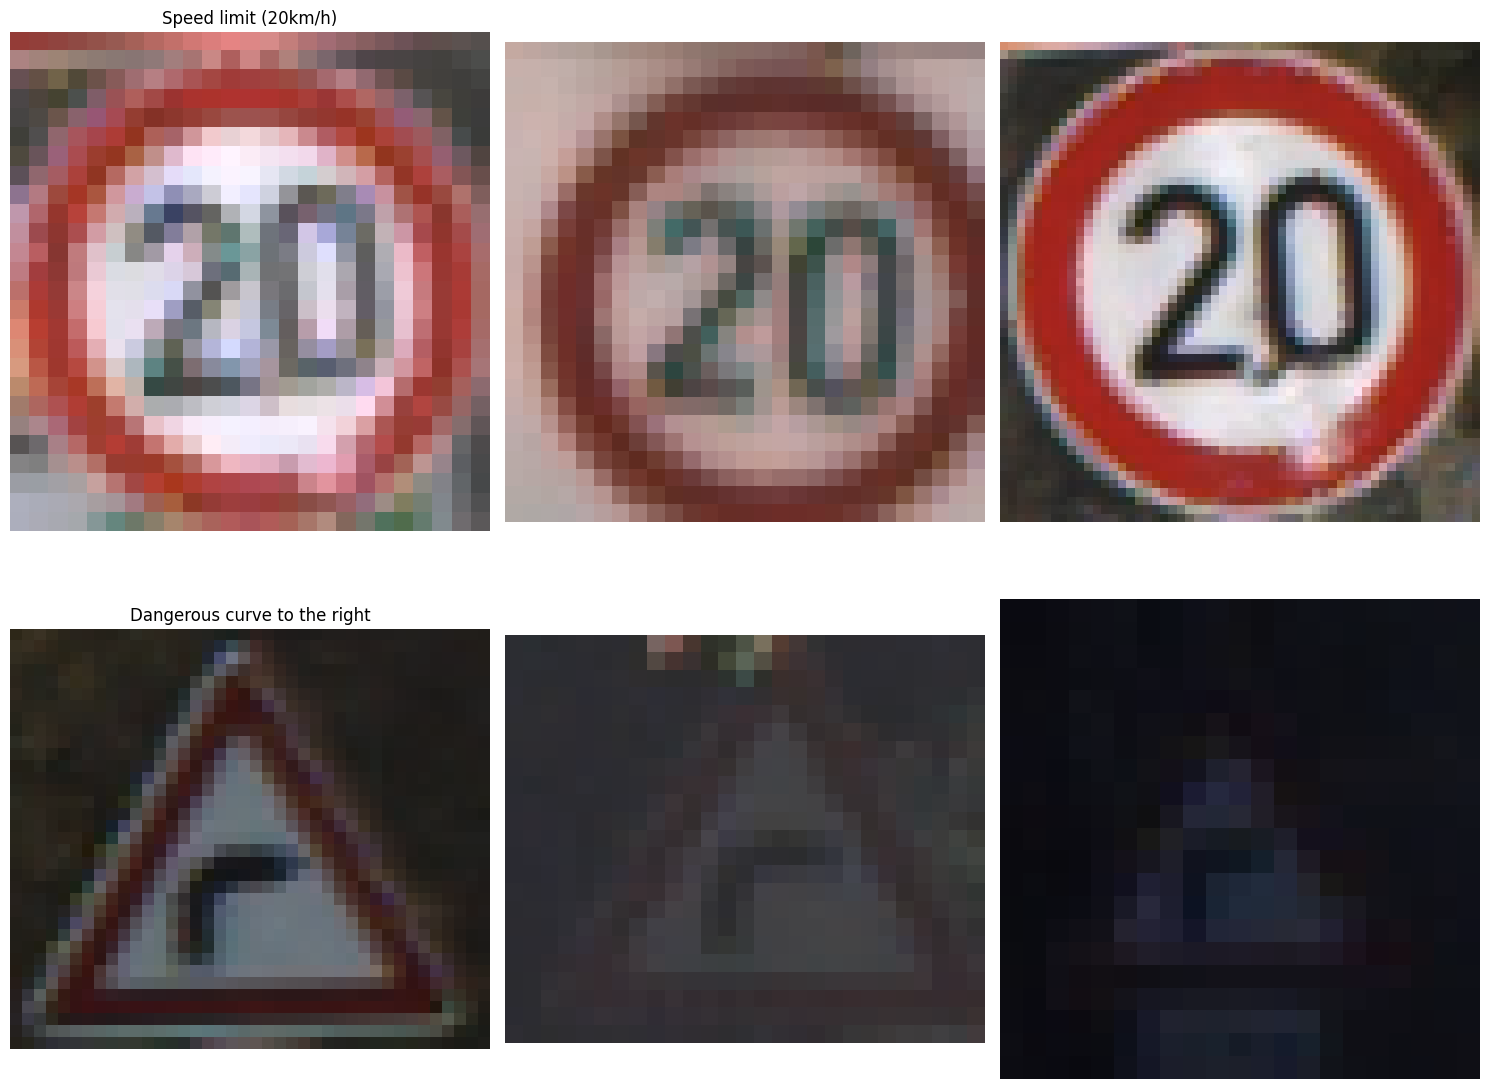

In [4]:
# Visualize sample images
dataset.visualize_samples(train_images, train_labels, samples_per_class=3, max_classes=10, figsize=(15, 12))

## Class Distribution

Let's check the distribution of classes in our dataset.

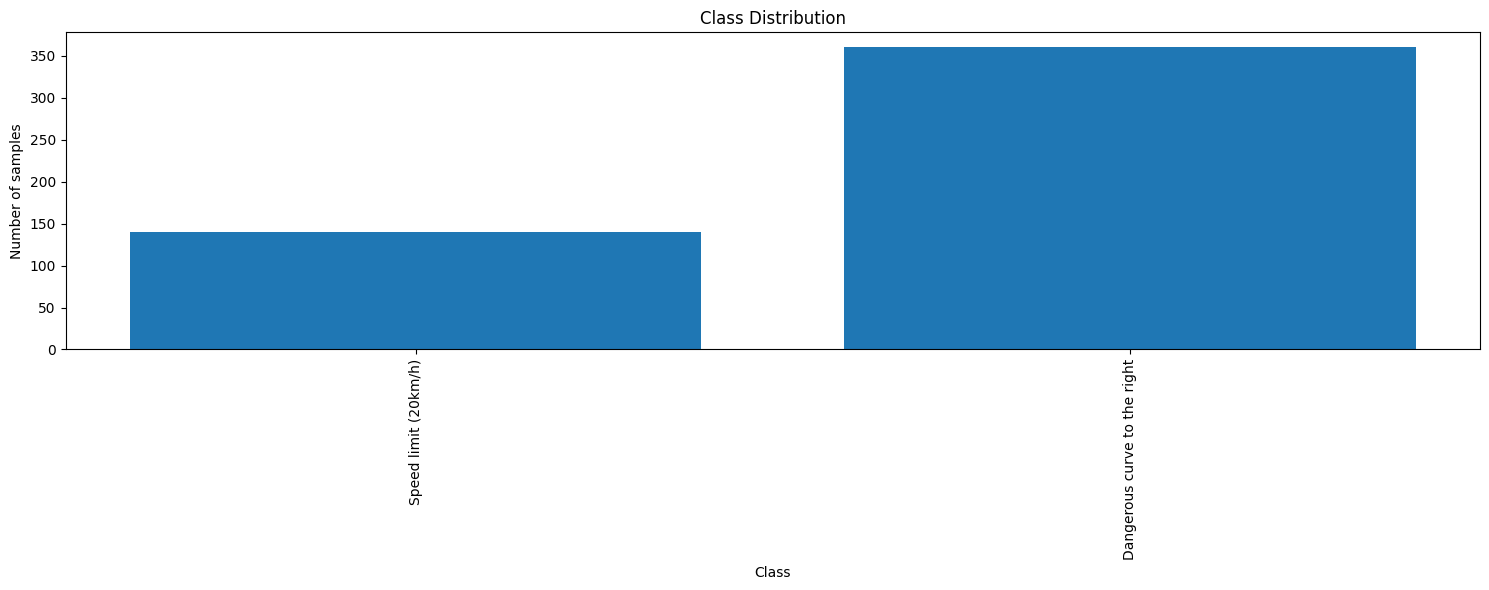

Total number of samples: 500
Number of classes: 2
Average samples per class: 250.0
Min samples for a class: 140 (Class 0)
Max samples for a class: 360 (Class 20)


In [5]:
# Plot class distribution
dataset.plot_class_distribution(train_labels, figsize=(15, 6))

## Preprocess Images

Now we'll preprocess our images by resizing them to a consistent size and normalizing the pixel values.


Processed images shape: (500, 32, 32, 3)
Value range: [0.00392156862745098, 1.0]


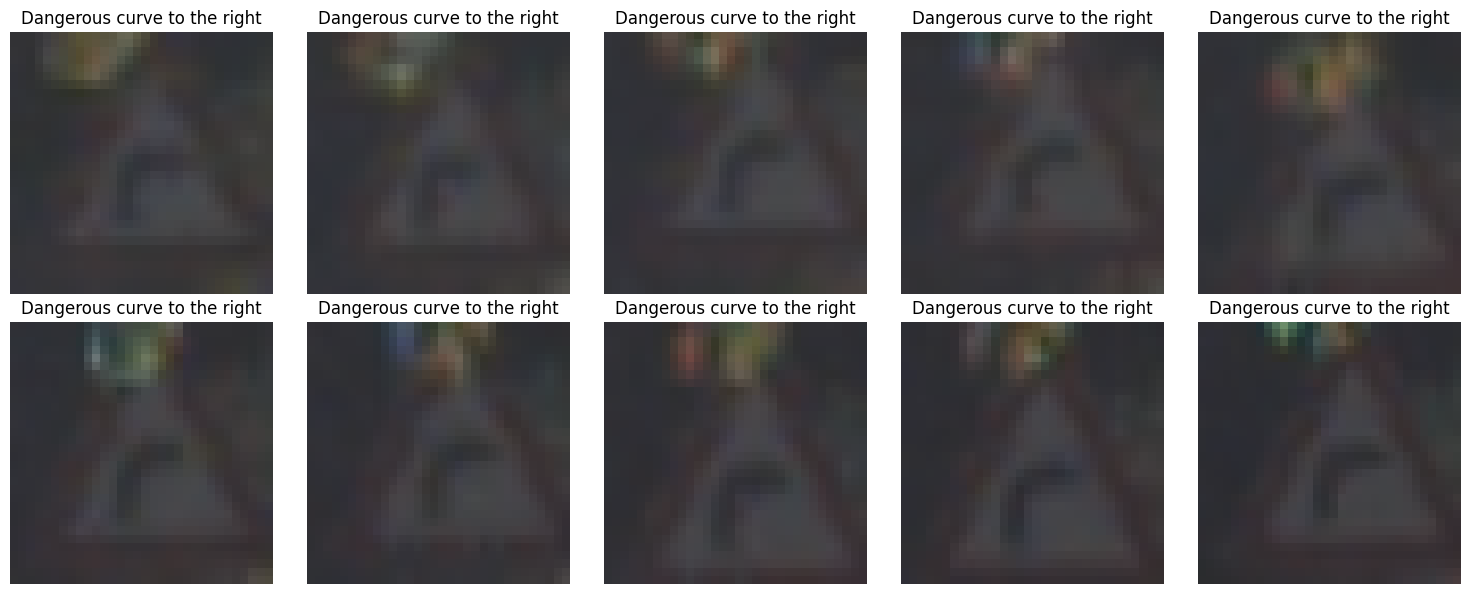

In [4]:
# Set the target size for our images
target_size = (32, 32)

# Preprocess the training images
train_images_processed = dataset.preprocess_data(train_images, target_size=target_size)

print(f"\nProcessed images shape: {train_images_processed.shape}")
print(f"Value range: [{train_images_processed.min()}, {train_images_processed.max()}]")

# Show some processed images
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images_processed[i])
    plt.title(f"{dataset.class_names.get(train_labels[i], f'Class {train_labels[i]}')}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Data Augmentation

Data augmentation is an important technique to increase the effective size of our dataset and improve model generalization. Let's see how our augmentation functions work on sample images.

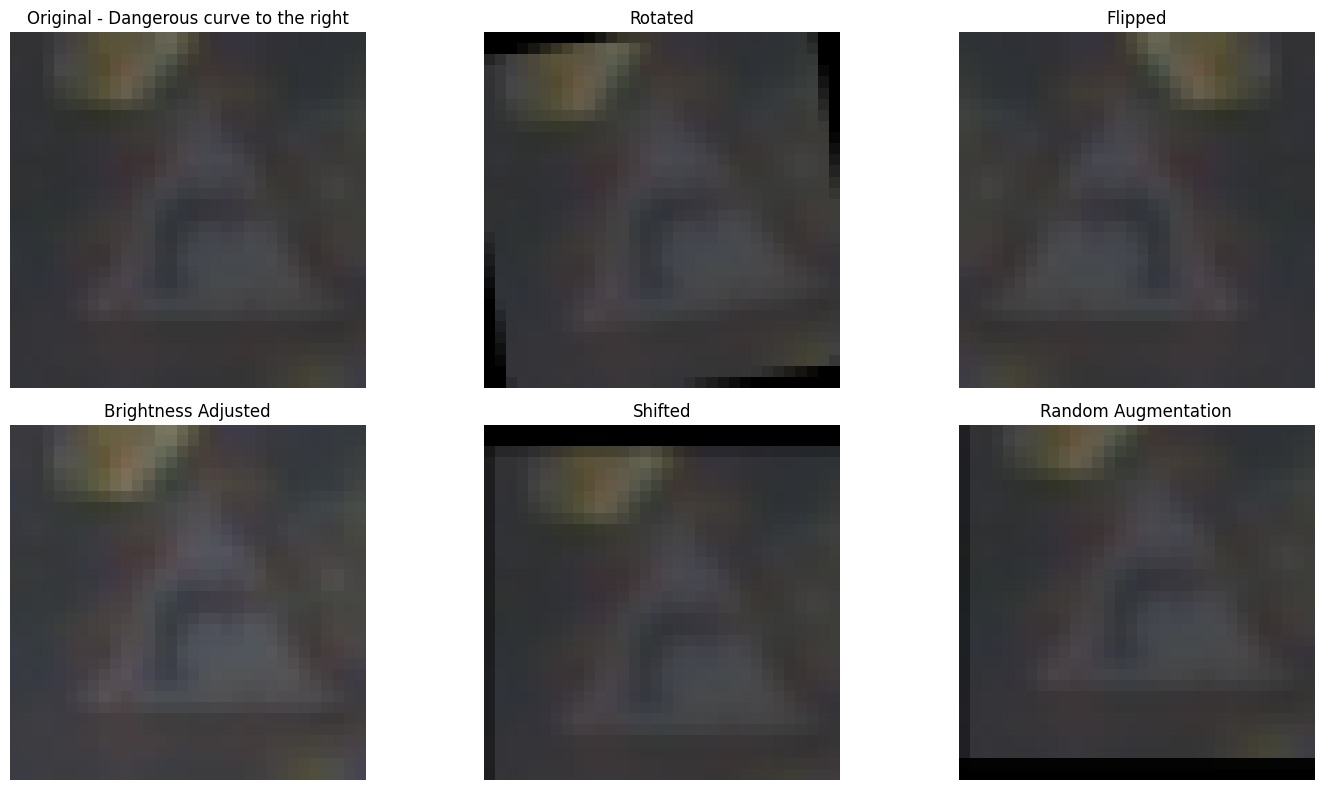

In [5]:
# Apply various augmentations to a sample image
sample_idx = 0  # Choose a sample image
sample_img = train_images_processed[sample_idx]
sample_label = train_labels[sample_idx]

# Convert to uint8 format if necessary for OpenCV functions
if sample_img.dtype != np.uint8 and np.max(sample_img) <= 1.0:
    sample_img_uint8 = (sample_img * 255).astype(np.uint8)
else:
    sample_img_uint8 = sample_img.copy()

plt.figure(figsize=(15, 8))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(sample_img)  # Display original processed image
plt.title(f"Original - {dataset.class_names.get(sample_label, f'Class {sample_label}')}")
plt.axis('off')

# Rotated image
plt.subplot(2, 3, 2)
rotated_img = apply_augmentation(sample_img_uint8, 'rotate')
plt.imshow(rotated_img / 255.0 if np.max(rotated_img) > 1.0 else rotated_img)
plt.title("Rotated")
plt.axis('off')

# Flipped image
plt.subplot(2, 3, 3)
flipped_img = apply_augmentation(sample_img_uint8, 'flip')
plt.imshow(flipped_img / 255.0 if np.max(flipped_img) > 1.0 else flipped_img)
plt.title("Flipped")
plt.axis('off')

# Brightness adjusted image
plt.subplot(2, 3, 4)
bright_img = apply_augmentation(sample_img_uint8, 'brightness')
plt.imshow(bright_img / 255.0 if np.max(bright_img) > 1.0 else bright_img)
plt.title("Brightness Adjusted")
plt.axis('off')

# Shifted image
plt.subplot(2, 3, 5)
shifted_img = apply_augmentation(sample_img_uint8, 'shift')
plt.imshow(shifted_img / 255.0 if np.max(shifted_img) > 1.0 else shifted_img)
plt.title("Shifted")
plt.axis('off')

# Random augmentation
plt.subplot(2, 3, 6)
random_img = apply_augmentation(sample_img_uint8, 'random')
plt.imshow(random_img / 255.0 if np.max(random_img) > 1.0 else random_img)
plt.title("Random Augmentation")
plt.axis('off')

plt.tight_layout()
plt.show()

## Load Test Data

Now let's load some test data to make sure our model will be able to evaluate on it properly.

Loaded CSV file with 12630 rows
Limited to first 100 samples
Processing image 0/100
Loaded 100 images with 32 unique classes

Loaded 100 test images with 32 unique classes


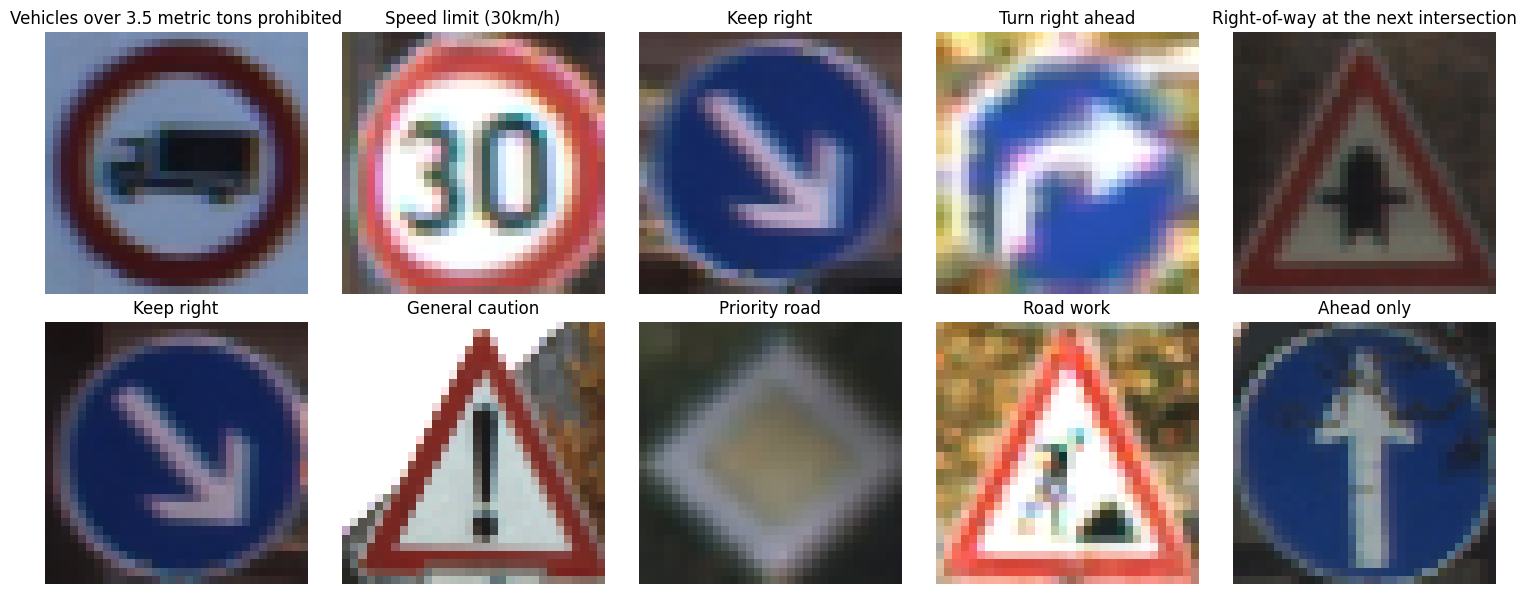

In [7]:
# Load test data (limit to 100 samples for exploration)
test_images, test_labels = dataset.load_test_data(limit=100)

print(f"\nLoaded {len(test_images)} test images with {len(np.unique(test_labels))} unique classes")

# Preprocess test images
test_images_processed = dataset.preprocess_data(test_images, target_size=target_size)

# Visualize some test images
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images_processed[i])
    plt.title(f"{dataset.class_names.get(test_labels[i], f'Class {test_labels[i]}')}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Data Splitting for Model Development

For model development, we typically split our data into training and validation sets. Since the GTSRB dataset already provides separate test data in the Test folder and Test.csv file, we'll only split the training data.

In [8]:
# Load a larger set of training data for model development
train_images_all, train_labels_all = dataset.load_train_data(limit=1000)  # Adjust limit as needed

# Preprocess
train_images_processed_all = dataset.preprocess_data(train_images_all, target_size=target_size)

# Split into train and validation sets only (we already have separate test data)
x_train, x_val, y_train, y_val = dataset.split_train_val(
    train_images_processed_all, train_labels_all, val_size=0.2, random_state=42
)

# Load some of the actual test data to use for final evaluation
test_images_final, test_labels_final = dataset.load_test_data(limit=200)  # Adjust limit as needed
x_test = dataset.preprocess_data(test_images_final, target_size=target_size)
y_test = test_labels_final

print(f"Training set: {len(x_train)} samples")
print(f"Validation set: {len(x_val)} samples")
print(f"Test set: {len(x_test)} samples (from Test.csv)")

Loaded CSV file with 39209 rows
Limited to first 1000 samples
Processing image 0/1000
Processing image 500/1000
Loaded 1000 images with 3 unique classes
Training set: 800 samples (80%)
Validation set: 200 samples (20%)
Loaded CSV file with 12630 rows
Limited to first 200 samples
Processing image 0/200
Loaded 200 images with 38 unique classes
Training set: 800 samples
Validation set: 200 samples
Test set: 200 samples (from Test.csv)
Loaded 1000 images with 3 unique classes
Training set: 800 samples (80%)
Validation set: 200 samples (20%)
Loaded CSV file with 12630 rows
Limited to first 200 samples
Processing image 0/200
Loaded 200 images with 38 unique classes
Training set: 800 samples
Validation set: 200 samples
Test set: 200 samples (from Test.csv)


## Create TensorFlow Datasets

Now let's create TensorFlow datasets for efficient batch processing during training. We'll create datasets for our training, validation, and test sets (from the actual test data).

In [9]:
from utils import create_tf_dataset

# Create TensorFlow datasets
batch_size = 32
train_ds = create_tf_dataset(x_train, y_train, batch_size=batch_size, shuffle=True, augment=True)
val_ds = create_tf_dataset(x_val, y_val, batch_size=batch_size, shuffle=False)
test_ds = create_tf_dataset(x_test, y_test, batch_size=batch_size, shuffle=False)

# Check the shape of our data
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}, labels shape: {labels.shape}")
    print(f"Labels: {labels.numpy()}")

Batch shape: (32, 32, 32, 3), labels shape: (32,)
Labels: [20 20 20  1  1 20  1  0  1  1  1 20  1 20 20 20  1  1  1  1 20 20 20  1
  1  1  0 20 20  1 20  1]


2025-05-20 16:22:28.074669: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
